# CC3092 — Laboratorio #2: Redes Neuronales Convolucionales

Clasificación multiclase de dígitos manuscritos (MNIST, 10 clases) comparando dos arquitecturas
entrenadas desde cero en PyTorch: un **MLP** que recibe la imagen aplanada y una **CNN** que la
recibe como tensor 2D.

## Parte 1: Imports y entorno

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from torchvision.datasets import MNIST
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Parte 2: Exploración y preparación de los datos

In [2]:
# MNIST viene ya separado en train (60k) y test (10k) por torchvision
train_full = MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_set = MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

print("Imágenes en train oficial:", len(train_full))
print("Imágenes en test oficial :", len(test_set))
print("Total                    :", len(train_full) + len(test_set))
print("Clases:", train_full.classes)

Imágenes en train oficial: 60000
Imágenes en test oficial : 10000
Total                    : 70000
Clases: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [3]:
# ¿están balanceadas las clases?
cnt_tr = pd.Series(train_full.targets.numpy()).value_counts().sort_index()
cnt_te = pd.Series(test_set.targets.numpy()).value_counts().sort_index()

dist = pd.DataFrame({"train (60k)": cnt_tr, "test (10k)": cnt_te})
dist["% train"] = (100 * dist["train (60k)"] / dist["train (60k)"].sum()).round(2)
dist.index.name = "dígito"
print(dist)
print(f"\nmin/max por clase en train: {cnt_tr.min()} / {cnt_tr.max()}")
print(f"desviación máxima respecto al 10% ideal: {(100 * cnt_tr / cnt_tr.sum() - 10).abs().max():.2f} pp")

        train (60k)  test (10k)  % train
dígito                                  
0              5923         980     9.87
1              6742        1135    11.24
2              5958        1032     9.93
3              6131        1010    10.22
4              5842         982     9.74
5              5421         892     9.04
6              5918         958     9.86
7              6265        1028    10.44
8              5851         974     9.75
9              5949        1009     9.91

min/max por clase en train: 5421 / 6742
desviación máxima respecto al 10% ideal: 1.24 pp


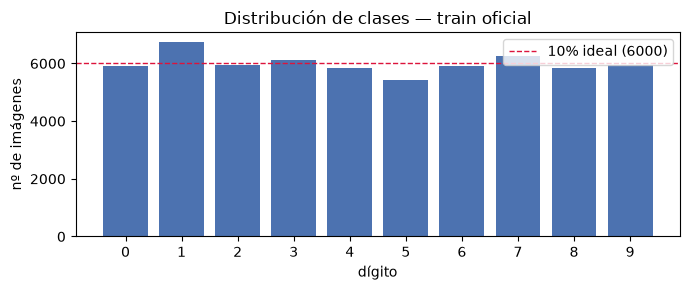

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(cnt_tr.index, cnt_tr.values, color="#4C72B0")
ax.axhline(len(train_full) / 10, color="crimson", ls="--", lw=1, label="10% ideal (6000)")
ax.set_xticks(range(10))
ax.set_xlabel("dígito")
ax.set_ylabel("nº de imágenes")
ax.set_title("Distribución de clases — train oficial")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# dimensión de cada imagen y rango de los píxeles
img, label = train_full[0]
raw = train_full.data  # tensor uint8 sin transformar

print("Tensor tras ToTensor():", tuple(img.shape), "| dtype:", img.dtype)
print(f"Rango tras ToTensor(): [{img.min():.1f}, {img.max():.1f}]")
print("Tensor crudo (dataset completo):", tuple(raw.shape), "| dtype:", raw.dtype)
print(f"Rango crudo: [{raw.min()}, {raw.max()}]")

x01 = raw.float() / 255.0
print(f"Media global (escala 0-1): {x01.mean():.4f} | Desv. estándar: {x01.std():.4f}")
print(f"Proporción de píxeles en 0 (fondo): {(raw == 0).float().mean():.2%}")

Tensor tras ToTensor(): (1, 28, 28) | dtype: torch.float32
Rango tras ToTensor(): [0.0, 1.0]
Tensor crudo (dataset completo): (60000, 28, 28) | dtype: torch.uint8
Rango crudo: [0, 255]


Media global (escala 0-1): 0.1307 | Desv. estándar: 0.3081


Proporción de píxeles en 0 (fondo): 80.88%


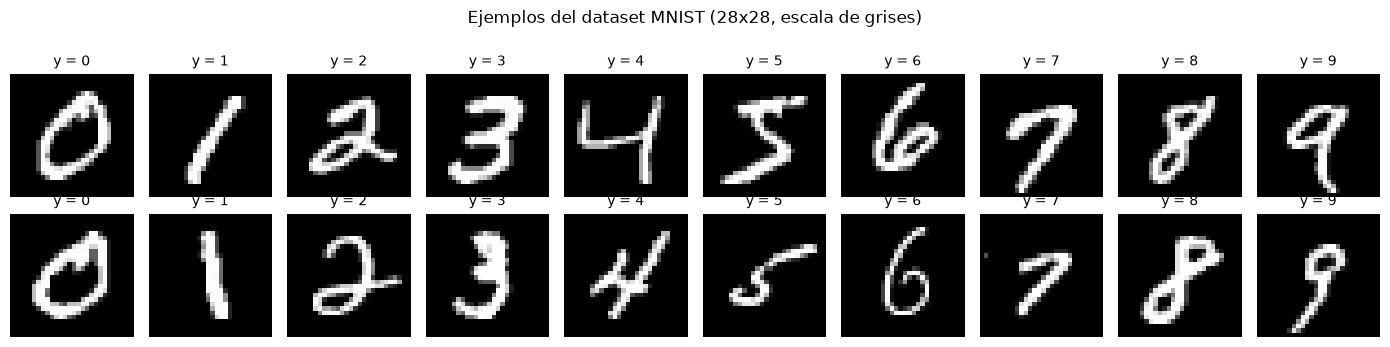

In [6]:
# 20 ejemplos: dos instancias distintas de cada dígito con su etiqueta
targets = train_full.targets.numpy()
fig, axes = plt.subplots(2, 10, figsize=(14, 3.4))
for d in range(10):
    idxs = np.where(targets == d)[0][:2]
    for row, i in enumerate(idxs):
        im, lab = train_full[i]
        axes[row, d].imshow(im.squeeze(), cmap="gray")
        axes[row, d].set_title(f"y = {lab}", fontsize=10)
        axes[row, d].axis("off")
plt.suptitle("Ejemplos del dataset MNIST (28x28, escala de grises)", y=1.02)
plt.tight_layout()
plt.show()

### División train / validación / test

El test oficial de 10 000 imágenes se reserva y **solo se usa una vez** al final. El train oficial de
60 000 se parte 80/20 en entrenamiento (48 000) y validación (12 000), que es el conjunto con el que
se comparan todas las iteraciones de hiperparámetros.

In [7]:
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(train_full), generator=g)
n_val = 12_000
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_all = train_full.data.float().div(255.0).unsqueeze(1)  # (60000, 1, 28, 28) en [0, 1]
y_all = train_full.targets.clone()

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test = test_set.data.float().div(255.0).unsqueeze(1)
y_test = test_set.targets.clone()

print("train:", tuple(X_train.shape), "| val:", tuple(X_val.shape), "| test:", tuple(X_test.shape))
print("clases en validación:", pd.Series(y_val.numpy()).value_counts().sort_index().to_dict())

train: (48000, 1, 28, 28) | val: (12000, 1, 28, 28) | test: (10000, 1, 28, 28)
clases en validación: {0: 1179, 1: 1293, 2: 1196, 3: 1247, 4: 1179, 5: 1097, 6: 1212, 7: 1218, 8: 1206, 9: 1173}


In [8]:
# normalización: estadísticos calculados SOLO con el split de entrenamiento
MEAN, STD = X_train.mean().item(), X_train.std().item()
print(f"mean = {MEAN:.4f} | std = {STD:.4f}")


def normalize(x):
    return (x - MEAN) / STD


X_train_n, X_val_n, X_test_n = normalize(X_train), normalize(X_val), normalize(X_test)
print(f"rango train normalizado: [{X_train_n.min():.2f}, {X_train_n.max():.2f}]")
print(f"media/std train normalizado: {X_train_n.mean():.4f} / {X_train_n.std():.4f}")

# los tres splits caben en VRAM (~220 MB), así se evita el cuello de botella del DataLoader
train_ds = TensorDataset(X_train_n.to(device), y_train.to(device))
val_ds = TensorDataset(X_val_n.to(device), y_val.to(device))
test_ds = TensorDataset(X_test_n.to(device), y_test.to(device))

val_loader = DataLoader(val_ds, batch_size=1024)
test_loader = DataLoader(test_ds, batch_size=1024)
print("datasets listos en", device)

mean = 0.1306 | std = 0.3081
rango train normalizado: [-0.42, 2.82]
media/std train normalizado: 0.0000 / 1.0000


datasets listos en cuda


### Respuestas — Parte 2

**¿Cuántas observaciones y cuántas clases tiene el dataset? ¿Están balanceadas?**

70 000 imágenes en total: 60 000 en el train oficial y 10 000 en el test oficial, con **10 clases**
(dígitos 0–9). Las clases están **prácticamente balanceadas pero no exactamente**: en train van de
5 421 imágenes (el 5, 9.04%) a 6 742 (el 1, 11.24%), es decir una desviación máxima de 1.24 puntos
porcentuales respecto al 10% ideal. Un desbalance de ese tamaño no exige ponderar la pérdida ni
remuestrear; sí justifica reportar métricas **macro** además de accuracy, para que las clases menos
frecuentes pesen igual en la evaluación.

**¿Cuál es la dimensión de cada imagen y qué rango de valores tienen los píxeles?**

Cada imagen es de **28x28 píxeles en un solo canal** (escala de grises). En crudo es un tensor `uint8`
con valores en **[0, 255]**; `ToTensor()` la convierte a `float32` de forma `(1, 28, 28)` en **[0, 1]**.
Aplanada son 784 features, que es la dimensión de entrada del MLP. El 80.9% de los píxeles son 0 puros:
la imagen es mayormente fondo negro con el trazo blanco centrado.

**¿Es necesario normalizar los valores de los píxeles?**

Sí. Con valores en [0, 255] los gradientes de la primera capa quedan a una escala dos órdenes de
magnitud mayor que los pesos, lo que obliga a learning rates diminutos y hace inestable el
entrenamiento. Aquí se aplican dos pasos: dividir por 255 (→ [0, 1]) y estandarizar con la media y
desviación del **split de entrenamiento** (`mean = 0.1306`, `std = 0.3081`, que coinciden con los
valores canónicos de MNIST). El resultado tiene media 0 y desviación 1, con rango [-0.42, 2.82].
Calcular los estadísticos solo con train evita filtrar información de validación/test.

**División de los datos**

- Entrenamiento: 48 000 imágenes (80% del train oficial).
- Validación: 12 000 imágenes (20%), con reparto por clase entre 1 097 y 1 293 → mantiene el balance del
  conjunto original.
- Test: las 10 000 imágenes oficiales, intactas hasta la evaluación final.

## Parte 3: Investigación — capas de PyTorch para la CNN

### Concepto previo: tensor

Un **tensor** (`torch.Tensor`) es un arreglo n-dimensional homogéneo, análogo a `np.ndarray`, pero con
dos capacidades extra: puede vivir en GPU (`.to("cuda")`) y registra las operaciones que lo producen
para que `autograd` calcule gradientes automáticamente (`requires_grad`, `.backward()`). Es la
estructura con la que viajan datos, parámetros y gradientes.

Las convenciones de forma que usa este lab:

| Objeto | Forma | Significado |
|---|---|---|
| Batch de imágenes | `(N, C, H, W)` | 128 imágenes de 1 canal 28x28 → `(128, 1, 28, 28)` |
| Entrada del MLP | `(N, D)` | la misma imagen aplanada → `(128, 784)` |
| Salida (logits) | `(N, K)` | una puntuación por clase → `(128, 10)` |

---

### 1. `nn.Conv2d`

**Propósito:** aplicar un banco de filtros (kernels) que se deslizan sobre la imagen. Cada filtro
aprende un patrón local (bordes, esquinas, trazos) y produce un *mapa de activación*; los pesos se
comparten entre todas las posiciones, lo que da **equivarianza a traslación** y muy pocos parámetros.

**Parámetros relevantes:**
- `in_channels` / `out_channels`: canales de entrada (1 en MNIST) y número de filtros a aprender.
- `kernel_size`: tamaño de la ventana (3 o 5 típicamente).
- `stride` (default 1): paso del deslizamiento; >1 reduce la resolución.
- `padding` (default 0): ceros añadidos al borde; `padding=k//2` conserva el tamaño espacial.
- `bias` (default `True`): redundante si va seguido de `BatchNorm2d`.

Tamaño de salida: `H_out = floor((H + 2p - k)/s) + 1`. Parámetros: `out*in*k*k + out`.

---

### 2. `nn.MaxPool2d`

**Propósito:** submuestrear tomando el **máximo** de cada ventana. Reduce resolución (menos cómputo),
amplía el campo receptivo y aporta invarianza a pequeños desplazamientos. No tiene parámetros
entrenables.

**Parámetros relevantes:** `kernel_size` (2 es lo habitual), `stride` (por defecto igual a
`kernel_size`), `padding`. Con `MaxPool2d(2)` una entrada 28x28 pasa a 14x14.

---

### 3. `nn.AvgPool2d`

**Propósito:** igual que el anterior pero promediando la ventana. Suaviza en lugar de quedarse con la
activación más fuerte, así que conserva información de intensidad media pero difumina los trazos
finos; en clasificación de dígitos normalmente rinde algo peor que max-pooling (se verifica en la
Parte 4). Mismos parámetros: `kernel_size`, `stride`, `padding`.

---

### 4. `nn.BatchNorm2d`

**Propósito:** normalizar cada canal usando la media y varianza del batch, y luego reescalarlo con dos
parámetros aprendidos por canal (`gamma`, `beta`). Estabiliza la distribución de activaciones, permite
learning rates más altos, acelera la convergencia y actúa como regularizador suave.

**Parámetros relevantes:** `num_features` (= `out_channels` de la conv previa), `eps`, `momentum` (para
las estadísticas móviles usadas en inferencia), `affine`. Distingue `model.train()` de `model.eval()`:
en entrenamiento usa estadísticos del batch, en evaluación los acumulados.

---

### 5. `nn.Flatten`

**Propósito:** aplanar las dimensiones espaciales para conectar la parte convolucional con las capas
densas: `(N, C, H, W) → (N, C*H*W)`. No tiene parámetros. En el MLP es la primera capa, la que
convierte `(N, 1, 28, 28)` en `(N, 784)`.

**Parámetros relevantes:** `start_dim` (default 1, preserva la dimensión de batch) y `end_dim`.

---

### 6. `nn.CrossEntropyLoss`

**Propósito:** pérdida estándar de clasificación multiclase. Combina `log_softmax` + `NLLLoss` en una
sola operación numéricamente estable, por lo que **la red debe emitir logits crudos, sin softmax
final**. Espera `input` de forma `(N, K)` y `target` entero de forma `(N,)` con las clases.

**Parámetros relevantes:** `weight` (pesos por clase para datos desbalanceados; innecesario en MNIST),
`label_smoothing`, `reduction` (`"mean"` por defecto), `ignore_index`.

---

### 7. Campo receptivo (*receptive field*)

El campo receptivo de una unidad es la región de la imagen de entrada que puede influir en su valor.
Crece al apilar capas: `RF_l = RF_{l-1} + (k_l - 1) * prod(strides anteriores)`. En la CNN base de este
lab (conv3x3 → pool2 → conv3x3 → pool2):

| Capa | k | stride acumulado | RF |
|---|---|---|---|
| conv1 3x3 | 3 | 1 | 3 |
| pool1 2x2 | 2 | 1 | 4 |
| conv2 3x3 | 3 | 2 | 8 |
| pool2 2x2 | 2 | 2 | 10 |

Se pasa de mirar 3x3 píxeles a mirar 10x10 sobre 28x28: las primeras capas detectan trazos locales y
las profundas combinan esos trazos en partes del dígito. Por eso una CNN necesita profundidad: sin
ella el campo receptivo nunca cubre la figura completa.

---

### 8. ¿Por qué una CNN necesita menos parámetros que un MLP equivalente?

Tres razones:

1. **Conectividad local:** cada unidad se conecta solo a una vecindad `k x k`, no a los 784 píxeles.
2. **Pesos compartidos:** el mismo filtro se reutiliza en todas las posiciones, así que su coste no
   depende del tamaño de la imagen.
3. **Submuestreo:** el pooling reduce la resolución antes de llegar a las capas densas, que son las
   que concentran casi todos los parámetros.

Además el sesgo inductivo es el correcto para imágenes: un MLP con la imagen aplanada pierde la
vecindad espacial (dos píxeles adyacentes acaban en posiciones arbitrarias del vector), mientras la
CNN la respeta por construcción. La celda siguiente cuantifica la diferencia.

In [9]:
conv = nn.Conv2d(1, 32, kernel_size=3, padding=1)      # (1,28,28) -> (32,28,28)
lin = nn.Linear(28 * 28, 32 * 28 * 28)                  # misma transformación, densa

p_conv = sum(p.numel() for p in conv.parameters())
p_lin = sum(p.numel() for p in lin.parameters())

print(f"Conv2d(1->32, 3x3, pad=1):        {p_conv:>12,} parámetros")
print(f"nn.Linear(784 -> 25088) equiv.:   {p_lin:>12,} parámetros")
print(f"Factor de reducción:              {p_lin / p_conv:>12,.0f}x")

Conv2d(1->32, 3x3, pad=1):                 320 parámetros
nn.Linear(784 -> 25088) equiv.:     19,694,080 parámetros
Factor de reducción:                    61,544x
